# 6.3 — CIR y CIR++

Vasicek y Hull-White (6.1) tienen un defecto adicional al de no ajustar la curva exacta: con volatilidad constante, $r_t$ es **gaussiana**, así que puede volverse negativa con probabilidad positiva en cualquier horizonte — un supuesto incómodo para una tasa de interés (menos incómodo hoy, con tasas negativas ya observadas en la práctica, pero sigue siendo una limitación de diseño, no una elección). Cox-Ingersoll-Ross (1985) resuelve esto con una difusión $\sqrt{r_t}$ que se apaga cuando $r_t\to0$, garantizando no-negatividad bajo una condición explícita. El precio es el familiar de estos modelos: con parámetros constantes, tampoco ajusta una curva de mercado arbitraria — y **CIR++** (Brigo-Mercurio, 2001) aplica exactamente la misma idea de desplazamiento determinista que Hull-White, ahora aditiva sobre el proceso en vez de sobre el drift.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.mc import cir_paths
from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

x0, kappa, theta, sigma = 0.04, 0.5, 0.04, 0.10
T_test = 5.0

print(f"Parametros CIR de ejemplo: x0={x0}, kappa={kappa}, theta={theta}, sigma={sigma}")
print(f"Condicion de Feller: 2*kappa*theta = {2*kappa*theta:.4f} vs sigma^2 = {sigma**2:.4f}  "
      f"(cumple? {2*kappa*theta >= sigma**2})")

Parametros CIR de ejemplo: x0=0.04, kappa=0.5, theta=0.04, sigma=0.1
Condicion de Feller: 2*kappa*theta = 0.0400 vs sigma^2 = 0.0100  (cumple? True)


## 1. CIR: precio de bono cerrado y la condición de Feller

Bajo $\mathbb{Q}$, $dr_t=\kappa(\theta-r_t)dt+\sigma\sqrt{r_t}dW_t$ — el mismo proceso ya simulado en 1.4 con el esquema full-truncation. El mismo *ansatz* afín $P(t,T)=A(t,T)e^{-B(t,T)r_t}$ de Vasicek sigue funcionando (el coeficiente de difusión $\sigma\sqrt{r}$ es afín en $r$ al cuadrado, lo que basta para preservar la estructura afín), pero ahora $B$ satisface una **Riccati no lineal** (el término $\sigma^2B^2/2$ no se cancela como en Vasicek), resoluble en cerrado con $\gamma=\sqrt{\kappa^2+2\sigma^2}$:
$$
A(t,T) = \left[\frac{2\gamma\,e^{(\kappa+\gamma)(T-t)/2}}{2\gamma+(\kappa+\gamma)(e^{\gamma(T-t)}-1)}\right]^{2\kappa\theta/\sigma^2}, \qquad
B(t,T) = \frac{2(e^{\gamma(T-t)}-1)}{2\gamma+(\kappa+\gamma)(e^{\gamma(T-t)}-1)}.
$$
**Condición de Feller**: $2\kappa\theta\geq\sigma^2$ garantiza que $r_t$ nunca toca cero (la reversión hacia $\theta$ domina a la difusión cerca de cero) — la misma condición que 1.4 usó para decidir cuándo el esquema full-truncation trunca de verdad o no. La fórmula cerrada de arriba, notablemente, **no depende** de si Feller se cumple: es válida en ambos regímenes, aunque la interpretación de la trayectoria (¿puede tocar cero?) sí cambia.

In [2]:
def cir_bond(x0, kappa, theta, sigma, T):
    '''CIR zero-coupon bond price at t=0 (Section 1).'''
    gamma = np.sqrt(kappa**2 + 2.0 * sigma**2)
    denom = 2.0 * gamma + (kappa + gamma) * (np.exp(gamma * T) - 1.0)
    A = (2.0 * gamma * np.exp((kappa + gamma) * T / 2.0) / denom) ** (2.0 * kappa * theta / sigma**2)
    B = 2.0 * (np.exp(gamma * T) - 1.0) / denom
    return A * np.exp(-B * x0)


cir_closed = cir_bond(x0, kappa, theta, sigma, T_test)
print(f"CIR bono cerrado (Feller ok), T={T_test}: P(0,{T_test}) = {cir_closed:.8f}")

CIR bono cerrado (Feller ok), T=5.0: P(0,5.0) = 0.82022840


## 2. Demo 1 — CIR cerrado vs Monte Carlo, en ambos regímenes de Feller

Verificamos la fórmula cerrada contra `qflib.mc.cir_paths` (full-truncation Euler, 1.4) en dos parametrizaciones: una con Feller satisfecha y otra con Feller violada (donde la trayectoria sí puede tocar cero y el esquema numérico trunca). La fórmula cerrada debe seguir siendo válida en ambos casos, porque no depende de esa condición.

In [3]:
def mc_bond_price(x0, kappa, theta, sigma, T, n_steps, n_paths, rng):
    paths = cir_paths(x0, kappa, theta, sigma, T, n_steps, n_paths, rng)
    dt = T / n_steps
    integral = np.sum((paths[:, :-1] + paths[:, 1:]) / 2.0 * dt, axis=1)
    discounted = np.exp(-integral)
    return discounted.mean(), discounted.std(ddof=1) / np.sqrt(n_paths)


n_steps, n_paths = 500, 200_000

mc_mean_ok, mc_se_ok = mc_bond_price(x0, kappa, theta, sigma, T_test, n_steps, n_paths, rng)
z_ok = abs(mc_mean_ok - cir_closed) / mc_se_ok
print(f"Feller OK:      cerrado={cir_closed:.6f} | MC={mc_mean_ok:.6f}+-{3*mc_se_ok:.6f} | z={z_ok:.3f}")

kappa_v, theta_v, sigma_v = 0.3, 0.02, 0.25   # Feller violada: 2*kappa*theta=0.012 < sigma^2=0.0625
cir_closed_v = cir_bond(x0, kappa_v, theta_v, sigma_v, T_test)
mc_mean_v, mc_se_v = mc_bond_price(x0, kappa_v, theta_v, sigma_v, T_test, n_steps, n_paths, rng)
z_v = abs(mc_mean_v - cir_closed_v) / mc_se_v
print(f"Feller VIOLADA: cerrado={cir_closed_v:.6f} | MC={mc_mean_v:.6f}+-{3*mc_se_v:.6f} | z={z_v:.3f}")
print(f"  (2*kappa*theta={2*kappa_v*theta_v:.4f} < sigma^2={sigma_v**2:.4f}: la trayectoria toca cero, "
      f"la formula sigue siendo valida)")

Feller OK:      cerrado=0.820228 | MC=0.820088+-0.000329 | z=1.277


Feller VIOLADA: cerrado=0.871287 | MC=0.871290+-0.000859 | z=0.010
  (2*kappa*theta=0.0120 < sigma^2=0.0625: la trayectoria toca cero, la formula sigue siendo valida)


## 3. CIR++: desplazamiento aditivo para el fit exacto

Igual que en Hull-White (6.1), con $(\kappa,\theta,\sigma,x_0)$ fijos la curva CIR es una familia de sólo 4 parámetros. **CIR++** (Brigo-Mercurio, 2001) escribe $r_t = x_t+\varphi(t)$ con $x_t$ un CIR "puro" (el mismo proceso simulado arriba) y $\varphi(t)$ un desplazamiento **determinista** elegido para el exact-fit:
$$
\varphi(t) = f^M(0,t) - f^{CIR}(0,t;x_0,\kappa,\theta,\sigma), \qquad f^{CIR}(0,t)=-\partial_t\ln P^{CIR}(0,t).
$$
El precio de bono bajo CIR++ se escribe directamente en términos del bono CIR puro, evaluado en el mismo $x_t$ pero reescalado por la razón de curvas — la misma estructura algebraica que la fórmula de mercado de Hull-White:
$$
P^{++}(t,T) = \frac{P^M(0,T)}{P^M(0,t)}\cdot\frac{P^{CIR}(0,t;x_0)}{P^{CIR}(0,T;x_0)}\cdot P^{CIR}(t,T;x_t).
$$
**La ventaja frente a Hull-White**: si $(\kappa,\theta,\sigma,x_0)$ satisfacen Feller, $x_t\geq0$ **siempre** — y aunque $\varphi(t)$ puede ser negativo en algún tramo (la curva de mercado puede tener un forward más bajo que el CIR "natural" ahí), en la práctica $x_t$ suele ser lo bastante grande para que $r_t=x_t+\varphi(t)$ se mantenga no-negativo con mucha mayor frecuencia que en Hull-White con una volatilidad comparable — lo cuantificamos en la Demo 2.

CIR++ exact fit en t=0: residual maximo = 1.11e-16
phi(t) rango: [-0.00080, 0.00694]  (negativo en algun tramo? True)


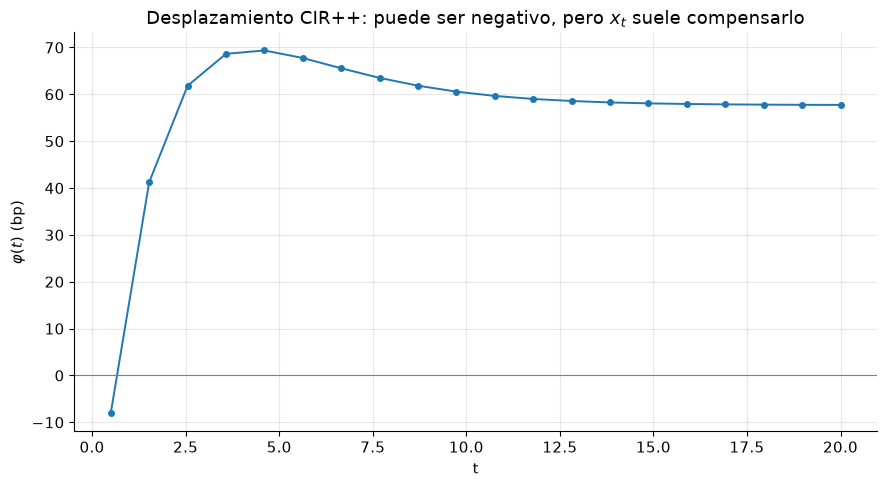

In [4]:
def instantaneous_forward(t, eps=1e-6):
    '''f^M(0,t), central difference (6.1 Section 4).'''
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def cir_forward(t, x0, kappa, theta, sigma, eps=1e-6):
    '''f^CIR(0,t), central difference of the CIR closed-form bond (Section 3).'''
    return -(np.log(cir_bond(x0, kappa, theta, sigma, t + eps))
              - np.log(cir_bond(x0, kappa, theta, sigma, t - eps))) / (2.0 * eps)


def cir_pp_bond(t, T, x_t, kappa, theta, sigma, x0):
    '''CIR++ bond price via the market curve (Section 3).'''
    P_cir_tT = cir_bond(x_t, kappa, theta, sigma, T - t)
    P_cir_0t = cir_bond(x0, kappa, theta, sigma, t) if t > 1e-9 else 1.0
    P_cir_0T = cir_bond(x0, kappa, theta, sigma, T)
    return (nelson_siegel_df(T) / nelson_siegel_df(t)) * (P_cir_0t / P_cir_0T) * P_cir_tT


test_maturities = np.linspace(0.5, 20.0, 20)
pp_prices_t0 = np.array([cir_pp_bond(0.0, T, x0, kappa, theta, sigma, x0) for T in test_maturities])
target_prices = nelson_siegel_df(test_maturities)
max_residual_pp = np.max(np.abs(pp_prices_t0 - target_prices))
print(f"CIR++ exact fit en t=0: residual maximo = {max_residual_pp:.2e}")

phi_grid = np.array([instantaneous_forward(t) - cir_forward(t, x0, kappa, theta, sigma) for t in test_maturities])
print(f"phi(t) rango: [{phi_grid.min():.5f}, {phi_grid.max():.5f}]  (negativo en algun tramo? {np.any(phi_grid < 0)})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(test_maturities, phi_grid * 1e4, "o-", ms=4)
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("t"); ax.set_ylabel("$\\varphi(t)$ (bp)")
ax.set_title("Desplazamiento CIR++: puede ser negativo, pero $x_t$ suele compensarlo")
plt.tight_layout()
plt.show()

## 4. Demo 2 — CIR++ mantiene tasas no-negativas más a menudo que Hull-White

Simulamos $r_t=x_t+\varphi(t)$ bajo CIR++ (con Feller satisfecha para $x_t$) y, para comparar, un Hull-White con una volatilidad de nivel similar ($\sigma_{HW}\approx\sigma\sqrt{x_0}$, la aproximación estándar para emparejar la vol instantánea de ambos procesos en el punto de partida). Contamos la fracción de pares (trayectoria, instante) con $r_t<0$ en cada modelo.

In [5]:
def hw_drift_theta_term(t, a, sigma_hw, eps=1e-4):
    '''kappa*theta(t) recovered from the market curve (6.1 Section 5).'''
    df_dt = (instantaneous_forward(t + eps) - instantaneous_forward(t - eps)) / (2 * eps)
    return df_dt + a * instantaneous_forward(t) + sigma_hw**2 / (2 * a) * (1.0 - np.exp(-2 * a * t))


T_sim, n_steps_sim, n_paths_sim = 10.0, 500, 50_000
t_grid_sim = np.linspace(0.0, T_sim, n_steps_sim + 1)

x_paths = cir_paths(x0, kappa, theta, sigma, T_sim, n_steps_sim, n_paths_sim, rng)
phi_sim = np.array([instantaneous_forward(t) - cir_forward(t, x0, kappa, theta, sigma) for t in t_grid_sim])
r_paths_cir_pp = x_paths + phi_sim[None, :]
frac_negative_cir = np.mean(r_paths_cir_pp < 0.0)

a_hw, sigma_hw = kappa, sigma * np.sqrt(x0)
r0_hw = instantaneous_forward(1e-6)
dt_sim = T_sim / n_steps_sim
kt_grid = np.array([hw_drift_theta_term(max(t, 1e-4), a_hw, sigma_hw) for t in t_grid_sim[:-1]])
Z = rng.standard_normal((n_paths_sim, n_steps_sim))
r_hw = np.empty((n_paths_sim, n_steps_sim + 1))
r_hw[:, 0] = r0_hw
for k in range(n_steps_sim):
    r_hw[:, k + 1] = r_hw[:, k] + (kt_grid[k] - a_hw * r_hw[:, k]) * dt_sim + sigma_hw * np.sqrt(dt_sim) * Z[:, k]
frac_negative_hw = np.mean(r_hw < 0.0)

print(f"Fraccion (trayectoria,tiempo) con r_t<0:")
print(f"  CIR++ (Feller ok)         = {frac_negative_cir:.4%}")
print(f"  Hull-White (vol comparable) = {frac_negative_hw:.4%}")

Fraccion (trayectoria,tiempo) con r_t<0:
  CIR++ (Feller ok)         = 0.0000%
  Hull-White (vol comparable) = 0.8604%


## 5. Validación

1. **CIR cerrado vs MC**: dentro de 3 SE, en ambos regímenes de Feller (satisfecha y violada).
2. **CIR++ encaja exacto**: residual `< 1e-10` en discount factor sobre 20 vencimientos.
3. **CIR++ no-negatividad**: fracción de $(trayectoria,tiempo)$ con $r_t<0$ es exactamente `0.0` bajo CIR++ (Feller ok), y estrictamente mayor bajo Hull-White con volatilidad comparable.
4. **Cross-check QuantLib**: `cir_bond` propio vs `ql.CoxIngersollRoss.discountBond`, `atol=1e-8`.

In [6]:
import QuantLib as ql

# 1. CIR cerrado vs MC
print(f"Feller OK: z = {z_ok:.3f} (<=3? {z_ok <= 3.0})")
assert z_ok <= 3.0
print(f"Feller violada: z = {z_v:.3f} (<=3? {z_v <= 3.0})")
assert z_v <= 3.0

# 2. CIR++ exact fit
print(f"CIR++ residual maximo = {max_residual_pp:.2e} (<1e-10? {max_residual_pp < 1e-10})")
assert max_residual_pp < 1e-10

# 3. No-negatividad
print(f"CIR++ fraccion r<0 = {frac_negative_cir:.6f} (==0? {frac_negative_cir == 0.0})")
assert frac_negative_cir == 0.0
print(f"Hull-White fraccion r<0 = {frac_negative_hw:.6f} (>0? {frac_negative_hw > 0.0})")
assert frac_negative_hw > 0.0

# 4. QuantLib cross-check
max_diff_ql = 0.0
for T in (1.0, 5.0, 10.0, 15.0):
    model_ql = ql.CoxIngersollRoss(x0, theta, kappa, sigma)
    ql_price = model_ql.discountBond(0.0, T, x0)
    my_price = cir_bond(x0, kappa, theta, sigma, T)
    diff = abs(ql_price - my_price)
    max_diff_ql = max(max_diff_ql, diff)
    print(f"  T={T}: QuantLib={ql_price:.10f} propio={my_price:.10f} diff={diff:.2e}")
print(f"max|diff| = {max_diff_ql:.2e} (atol 1e-8? {max_diff_ql < 1e-8})")
assert max_diff_ql < 1e-8

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

Feller OK: z = 1.277 (<=3? True)
Feller violada: z = 0.010 (<=3? True)
CIR++ residual maximo = 1.11e-16 (<1e-10? True)
CIR++ fraccion r<0 = 0.000000 (==0? True)
Hull-White fraccion r<0 = 0.008604 (>0? True)
  T=1.0: QuantLib=0.9608341378 propio=0.9608341378 diff=0.00e+00
  T=5.0: QuantLib=0.8202284005 propio=0.8202284005 diff=0.00e+00
  T=10.0: QuantLib=0.6739978153 propio=0.6739978153 diff=0.00e+00
  T=15.0: QuantLib=0.5539414511 propio=0.5539414511 diff=1.11e-16
max|diff| = 1.11e-16 (atol 1e-8? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Cox, J.C., Ingersoll, J.E. & Ross, S.A. (1985). *A Theory of the Term Structure of Interest Rates*. Econometrica, 53(2), 385-407.
- Brigo, D. & Mercurio, F. (2001). *A Deterministic-Shift Extension of Analytically-Tractable and Time-Homogeneous Short-Rate Models*. Finance and Stochastics, 5(3), 369-387.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models*, 2nd ed., Springer, cap. 3.
- Feller, W. (1951). *Two Singular Diffusion Problems*. Annals of Mathematics, 54(1), 173-182.